# Notebook 05B - PubMedBERT Fine-Tuning

## PubMedBert Environment Setup and Library Imports 

This section initialises the environment and imports all required libraries for fine-tuning and evaluating the PubMedBERT model on the clinical readmission prediction task.

The setup includes core data handling libraries (NumPy, pandas), PyTorch utilities for dataset management, and Hugging Face Transformers components for model training and optimisation. Evaluation metrics such as ROC-AUC and Precision–Recall AUC are included to enable robust performance assessment, particularly under class imbalance.

Project-specific configuration parameters are imported from a central configuration file to ensure consistency across experiments, including dataset paths, model identifiers, hyperparameters, and output directories.

A dedicated directory is created for storing PubMedBERT visualisations, and global plotting settings are applied to maintain a consistent visual style across all generated figures.

This structured setup ensures reproducibility, modularity, and alignment with the previously implemented DistilBERT pipeline.

In [1]:
# System Path Configuration
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# Core Data Handling Libraries
import pandas as pd
import numpy as np
import pickle

# PyTorch Utilities
import torch
from torch.utils.data import Dataset

# Visualisation and Warning Control
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Hugging Face Transformers Components
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

# Scikit-learn Utilities
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)

# Evaluation Library
import evaluate

# Project Configuration Parameters
from config import (
    LABELLED_DATASET,
    PUBMEDBERT_MODEL_ID,
    PUBMEDBERT_DIR,
    PUBMEDBERT_RESULTS_CSV,
    PUBMEDBERT_PREDS_PKL,
    DISTILBERT_MODEL_ID,
    PLOTS_DIR,
    MAX_LENGTH,
    NUM_EPOCHS,
    BATCH_SIZE,
    LEARNING_RATE,
    WEIGHT_DECAY,
    WARMUP_STEPS,
    EARLY_STOPPING_PATIENCE,
    RANDOM_STATE,
    TEST_SIZE,
    VAL_SIZE,
    NUM_LABELS,
)


# Create PubMedBERT Plot Save Directory
PUBMEDBERT_PLOTS_DIR = PLOTS_DIR / "pubmedbert_model"
PUBMEDBERT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Global Plotting Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F', '#8338EC']

## Data Preparation and Experimental Setup 

This section prepares the dataset and experimental environment for fine-tuning PubMedBERT on the readmission prediction task.

Reproducibility is ensured by fixing random seeds across all libraries. GPU acceleration is utilised when available, with mixed-precision (FP16) enabled to improve computational efficiency.

The labelled dataset is loaded and split into training, validation, and test sets using stratified sampling. This preserves the class distribution across all splits, which is critical for imbalanced clinical prediction tasks. The same random seed and split strategy as previous experiments are used to ensure fair comparison with baseline models and DistilBERT.

To address class imbalance, class weights are computed using the balanced weighting scheme. These weights are later incorporated into the loss function during training, ensuring that minority class instances (readmitted patients) are appropriately emphasised.

Finally, dataset statistics are reported to verify split sizes and label distributions, confirming correct preprocessing before model training.

In [2]:
# Reproducibility Setup
set_seed(RANDOM_STATE)

# cuDNN Configuration for Performance Optimisation
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

# Device Selection 
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_FP16 = (device.type == 'cuda')

# Dataset Loading
df = pd.read_csv(LABELLED_DATASET)

# Feature and Label Extraction
X = df['narrative'].to_numpy(dtype=str)
y = df['readmission_30d'].to_numpy(dtype=int)

# Train / Validation / Test Split (Stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Class Weight Computation 
cw_arr = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

cw_dict = {
    0: float(cw_arr[0]),
    1: float(cw_arr[1])
}

# Dataset Summary Statistics
print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')
print(f'Train label dist : {np.bincount(y_train)}')
print(f'Class weights : {cw_dict}')

Train : 28,876  |  Val : 3,610  |  Test : 3,610
Train label dist : [23325  5551]
Class weights : {0: 0.6189924973204716, 1: 2.600972797694109}


## Tokenisation Efficiency Analysis: PubMedBERT vs DistilBERT

This section compares the tokenisation behaviour of DistilBERT and PubMedBERT on domain-specific clinical terminology.

Transformer models rely on subword tokenisation, where words may be split into smaller units depending on vocabulary coverage. General-domain models such as DistilBERT often fragment specialised medical terms into multiple subword tokens, increasing sequence length and reducing effective context utilisation.

In contrast, PubMedBERT is pretrained on biomedical corpora and is expected to encode clinical terms more efficiently, resulting in fewer tokens per term. This improves representation quality and allows more meaningful content to fit within the fixed maximum sequence length.

A set of representative clinical phrases is evaluated, and token counts are compared across both models. The difference in token counts (tokens saved) provides a direct measure of tokenisation efficiency.

This analysis provides empirical evidence for the advantage of domain-specific pretraining and supports the hypothesis that PubMedBERT is better suited for clinical NLP tasks.

In [3]:
# Tokeniser Loading (PubMedBERT and DistilBERT for Comparison)
tok_pm = AutoTokenizer.from_pretrained(PUBMEDBERT_MODEL_ID)
tok_db = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_ID)

# Clinical Terms for Tokenisation Comparison
clinical_terms = [
    'myocardial infarction',
    'percutaneous coronary intervention',
    'hypertensive heart disease',
    'estimated glomerular filtration rate',
    'metoprolol tartrate',
    'cerebrovascular accident',
    'electrocardiogram',
    'hyperlipidaemia',
]

# Token Length Comparison Output
print(f'\n{"Term":<42}  {"DistilBERT":>12}  {"PubMedBERT":>12}  {"Saved":>7}')
print('-' * 80)

total_db = total_pm = 0

for term in clinical_terms:
    n_db = len(tok_db.tokenize(term))
    n_pm = len(tok_pm.tokenize(term))
    saved = n_db - n_pm
    print(f'{term:<42}  {n_db:>12}  {n_pm:>12}  {saved:>+7}')
    total_db += n_db
    total_pm += n_pm

print(f'\n{"TOTAL":<42}  {total_db:>12}  {total_pm:>12}  {total_db - total_pm:>+7}')


Term                                          DistilBERT    PubMedBERT    Saved
--------------------------------------------------------------------------------
myocardial infarction                                  6             2       +4
percutaneous coronary intervention                     6             3       +3
hypertensive heart disease                             5             3       +2
estimated glomerular filtration rate                   9             4       +5
metoprolol tartrate                                    7             5       +2
cerebrovascular accident                               6             2       +4
electrocardiogram                                      4             1       +3
hyperlipidaemia                                        4             4       +0

TOTAL                                                 47            24      +23


## Tokenised Dataset Construction
This section defines a custom PyTorch dataset for efficiently handling tokenised clinical narratives during model training and evaluation.

Each input narrative is transformed into token IDs using the PubMedBERT tokenizer, with truncation and padding applied to ensure a fixed sequence length. This guarantees compatibility with transformer input requirements while maintaining batch consistency.

The dataset class encapsulates both tokenised inputs and corresponding labels, enabling seamless integration with the Hugging Face Trainer API. Each sample returned by the dataset includes input IDs, attention masks, and labels in tensor format.

Separate dataset instances are created for the training, validation, and test splits, ensuring a clean separation of data across the experimental pipeline.

This modular design improves code clarity, reusability, and computational efficiency during model training.

In [4]:
# Custom PyTorch Dataset for Tokenised Inputs
class ClinicalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        # Text Tokenisation (Padding + Truncation)
        self.enc = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        # Label Tensor Conversion
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        # Dataset Size
        return len(self.labels)

    def __getitem__(self, idx):
        # Retrieve Encoded Inputs and Corresponding Label
        item = {k: v[idx] for k, v in self.enc.items()}
        item['labels'] = self.labels[idx]
        return item

# Dataset Instantiation (Train / Validation / Test)
train_ds = ClinicalDataset(X_train, y_train, tok_pm)
val_ds = ClinicalDataset(X_val,   y_val,   tok_pm)
test_ds  = ClinicalDataset(X_test,  y_test,  tok_pm)

## Class-Imbalance Handling and Evaluation Metrics 

This section defines a custom training strategy and evaluation framework tailored to the imbalanced clinical prediction task.

To address class imbalance, a custom Trainer is implemented with a class-weighted cross-entropy loss. This ensures that minority class instances (readmitted patients) contribute more significantly to the optimisation objective, improving recall and overall model sensitivity.

The class weights, computed during preprocessing, are incorporated directly into the loss function and applied during each training step. This approach mitigates bias toward the majority class and leads to more balanced predictions.

For evaluation, multiple performance metrics are computed to provide a comprehensive assessment of model performance. In addition to accuracy, weighted F1-score is used to account for class imbalance, while ROC-AUC and PR-AUC capture ranking performance and precision–recall trade-offs.

The evaluation pipeline converts logits into probabilities using softmax, enabling threshold-independent metrics such as ROC-AUC and PR-AUC. Safe handling is included to prevent metric computation errors in edge cases.

This combination of weighted optimisation and robust evaluation ensures that the model is assessed in a statistically meaningful and clinically relevant manner.

In [5]:
# Custom Trainer with Class-Weighted Loss
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # Class Weight Tensor (Moved to Device)
        w = torch.tensor(
            [class_weights[0], class_weights[1]],
            dtype=torch.float
        ).to(device)

        # Weighted Cross-Entropy Loss
        self.loss_fn = torch.nn.CrossEntropyLoss(weight=w)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Extract Labels and Forward Pass
        labels  = inputs.pop('labels')
        outputs = model(**inputs)

        # Compute Weighted Loss
        loss = self.loss_fn(outputs.logits, labels)

        return (loss, outputs) if return_outputs else loss


# Accuracy Metric Initialisation
acc_metric = evaluate.load('accuracy')


# Evaluation Metrics Function
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Predictions and Probabilities
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(
        torch.tensor(logits, dtype=torch.float32),
        dim=-1
    ).numpy()[:, 1]

    # Accuracy Computation
    acc = acc_metric.compute(
        predictions=preds,
        references=labels
    )['accuracy']

    # Classification Report (Weighted F1)
    rep = classification_report(
        labels,
        preds,
        output_dict=True,
        zero_division=0
    )

    # ROC-AUC and PR-AUC 
    try:
        roc = roc_auc_score(labels, probs)
        pr  = average_precision_score(labels, probs)
    except ValueError:
        roc = pr = 0.0

    # Metric Dictionary
    return {
        'accuracy' : acc,
        'f1_weighted' : rep['weighted avg']['f1-score'],
        'roc_auc' : roc,
        'pr_auc' : pr,
    }

## Model Initialisation and Resource Allocation (PubMedBERT)

This section initialises the PubMedBERT model for sequence classification and prepares it for training.

Before loading the model, GPU memory is cleared to ensure efficient resource utilisation and avoid potential memory allocation issues. When a CUDA-enabled device is available, computations are offloaded to the GPU to accelerate training.

The PubMedBERT model is loaded with a sequence classification head, configured for binary classification. The number of output labels is specified to align with the readmission prediction task.

After initialisation, the model is moved to the selected device (GPU or CPU). The total and trainable parameter counts are computed to provide insight into model complexity and training capacity.

This step confirms that the model is correctly configured and ready for fine-tuning within the training pipeline.

In [6]:
# GPU Memory Check (Before Model Loading)
if device.type == 'cuda':
    torch.cuda.empty_cache()
    vram_before = torch.cuda.memory_allocated(0) / 1e9

# Model Initialisation (Sequence Classification Head)
model = AutoModelForSequenceClassification.from_pretrained(
    PUBMEDBERT_MODEL_ID,
    num_labels=NUM_LABELS
)

# Move Model to Device
model.to(device)

# Parameter Count (Total and Trainable)
total_p = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Parameters  : {total_p:,} total  |  {trainable_p:,} trainable')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1258.20it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                   

Parameters  : 109,483,778 total  |  109,483,778 trainable


## Training Configuration and Fine-Tuning Strategy (PubMedBERT)

This section defines the training configuration and executes fine-tuning of the PubMedBERT model.

Training hyperparameters, including learning rate, batch size, weight decay, and number of epochs, are specified through the Hugging Face TrainingArguments interface. A linear warmup strategy is applied to stabilise early training dynamics and prevent large gradient updates.

Evaluation is performed at the end of each epoch, and model checkpoints are saved periodically. The best-performing model is selected based on validation ROC-AUC, ensuring that the chosen model reflects optimal ranking performance under class imbalance.

Mixed-precision training (FP16) is enabled when using a GPU, improving computational efficiency and reducing memory usage. Early stopping is incorporated to prevent overfitting by halting training when validation performance no longer improves.

The custom WeightedTrainer is used to incorporate class-weighted loss, ensuring balanced optimisation across classes.

Finally, the training process is executed, and total runtime is reported to provide insight into computational cost.

In [7]:
# Training Arguments Configuration
training_args = TrainingArguments(
    output_dir = PUBMEDBERT_DIR,
    num_train_epochs = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size = BATCH_SIZE * 2,
    learning_rate = LEARNING_RATE,
    warmup_steps = WARMUP_STEPS,
    weight_decay = WEIGHT_DECAY,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model = 'roc_auc',
    greater_is_better = True,
    fp16 = USE_FP16,
    dataloader_pin_memory = (device.type == 'cuda'),
    dataloader_num_workers = 0,
    logging_steps = 50,
    report_to = 'none',
    seed = RANDOM_STATE,
)

# Trainer Initialisation
trainer = WeightedTrainer(
    class_weights = cw_dict,
    model = model,
    args = training_args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    compute_metrics = compute_metrics,
    callbacks = [
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE
        )
    ],
)

# Training Start Notification
print('Starting PubMedBERT fine-tuning...')

# Model Training Execution
train_result = trainer.train()

# Training Runtime Summary
runtime_min = train_result.metrics['train_runtime'] / 60
print(f'Training complete in {runtime_min:.1f} min')

Starting PubMedBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Roc Auc,Pr Auc
1,0.644706,0.625804,0.631302,0.670132,0.710055,0.405524
2,0.636985,0.610528,0.702216,0.726976,0.722505,0.445867
3,0.592106,0.620833,0.690859,0.718971,0.720297,0.432005
4,0.549831,0.651234,0.734903,0.749153,0.708869,0.425482
5,0.518282,0.721849,0.685596,0.714064,0.702989,0.407452


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.23it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training complete in 22.5 min


## Training Dynamics and Convergence Analysis 

This section visualises the training dynamics of PubMedBERT during fine-tuning to assess convergence behaviour and model stability.

Training loss is plotted against optimisation steps to evaluate how effectively the model learns from the data. A smooth downward trend indicates stable optimisation, while fluctuations may suggest instability or learning rate issues.

Validation performance is monitored across epochs using ROC-AUC and weighted F1-score. ROC-AUC provides insight into the model’s ranking ability under class imbalance, while weighted F1-score reflects overall classification performance accounting for class distribution.

Tracking these metrics over time enables identification of:
- Convergence trends and training stability  
- Potential overfitting (divergence between training loss and validation metrics)  
- Optimal stopping point for model selection  

These curves provide critical evidence that the training process is well-behaved and that early stopping and model selection are appropriately justified.

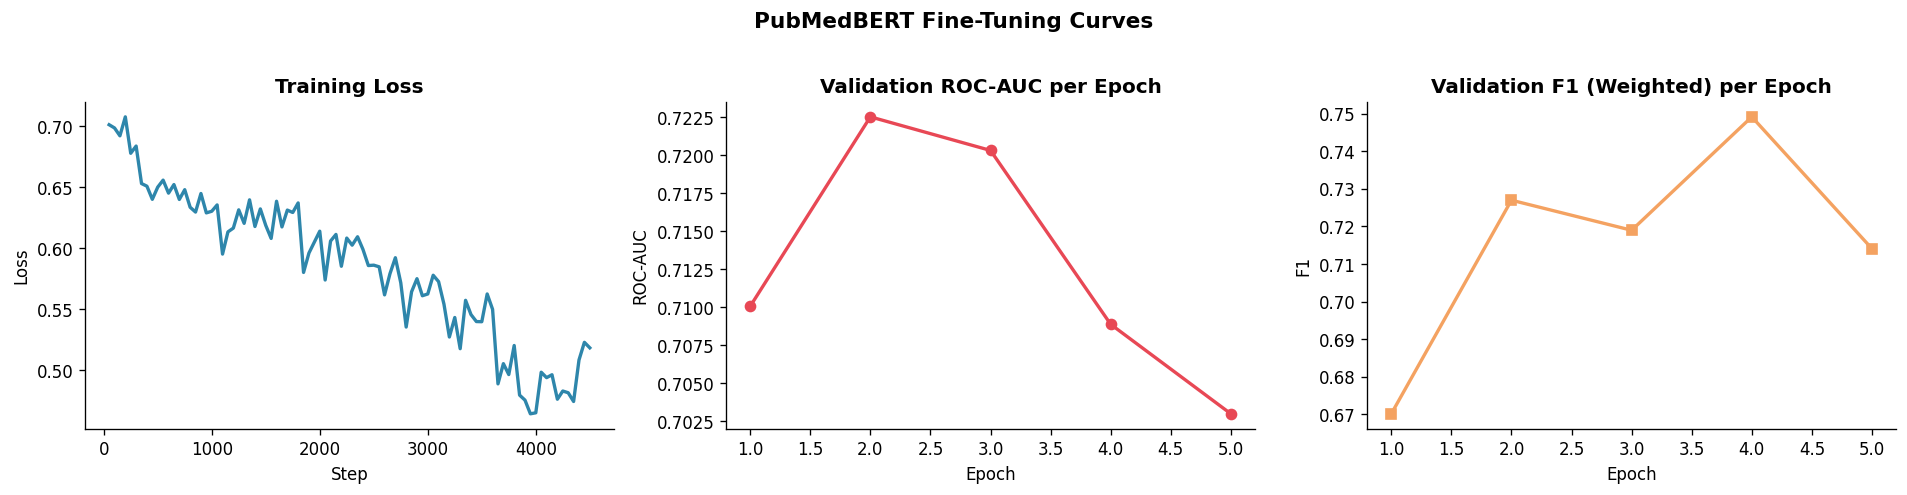

In [8]:
# Extract Training and Evaluation Logs
log_history = trainer.state.log_history

train_logs = [
    x for x in log_history
    if 'loss' in x and 'eval_loss' not in x
]

eval_logs = [
    x for x in log_history
    if 'eval_loss' in x
]

# Plot Training Curves (If Logs Available)
if train_logs and eval_logs:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Training Loss vs Steps
    axes[0].plot(
        [x['step'] for x in train_logs],
        [x['loss'] for x in train_logs],
        color=PALETTE[0],
        lw=2
    )
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')

    # Validation ROC-AUC per Epoch
    axes[1].plot(
        [x['epoch'] for x in eval_logs],
        [x.get('eval_roc_auc', 0) for x in eval_logs],
        'o-',
        color=PALETTE[1],
        lw=2,
        markersize=6
    )
    axes[1].set_title('Validation ROC-AUC per Epoch', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('ROC-AUC')

    # Validation Weighted F1 per Epoch
    axes[2].plot(
        [x['epoch'] for x in eval_logs],
        [x.get('eval_f1_weighted', 0) for x in eval_logs],
        's-',
        color=PALETTE[2],
        lw=2,
        markersize=6
    )
    axes[2].set_title('Validation F1 (Weighted) per Epoch', fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1')

    # Figure Formatting and Save
    plt.suptitle(
        'PubMedBERT Fine-Tuning Curves',
        fontsize=13,
        fontweight='bold',
        y=1.02
    )
    plt.tight_layout()

    plt.savefig(
        f'{PUBMEDBERT_PLOTS_DIR}/pm_01_training_curves.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

## Test Set Evaluation and Performance Analysis (PubMedBERT)

This section evaluates the performance of the fine-tuned PubMedBERT model on the held-out test set.

Predictions are generated using the trained model, and logits are converted into class probabilities using the softmax function. These probabilities enable the computation of threshold-independent evaluation metrics, which are essential for imbalanced classification tasks.

Performance is assessed using multiple metrics:
- **ROC-AUC** evaluates the model’s ability to rank positive instances higher than negative ones.
- **PR-AUC** is particularly important in imbalanced settings, capturing the trade-off between precision and recall.
- **Classification report** provides detailed class-wise metrics, including precision, recall, and F1-score.

To provide a comprehensive visual analysis, three plots are generated:
1. **ROC Curve**, illustrating the trade-off between true positive rate and false positive rate.
2. **Precision–Recall Curve**, highlighting performance on the minority class.
3. **Confusion Matrix**, showing the distribution of correct and incorrect predictions.

Together, these metrics and visualisations provide a complete assessment of model performance, enabling comparison with baseline models and other transformer architectures.


 PubMedBERT - Test Set Results 
                precision    recall  f1-score   support

Not Readmitted       0.88      0.72      0.79      2916
    Readmitted       0.33      0.57      0.42       694

      accuracy                           0.69      3610
     macro avg       0.60      0.65      0.60      3610
  weighted avg       0.77      0.69      0.72      3610

ROC-AUC : 0.7068   PR-AUC : 0.4003


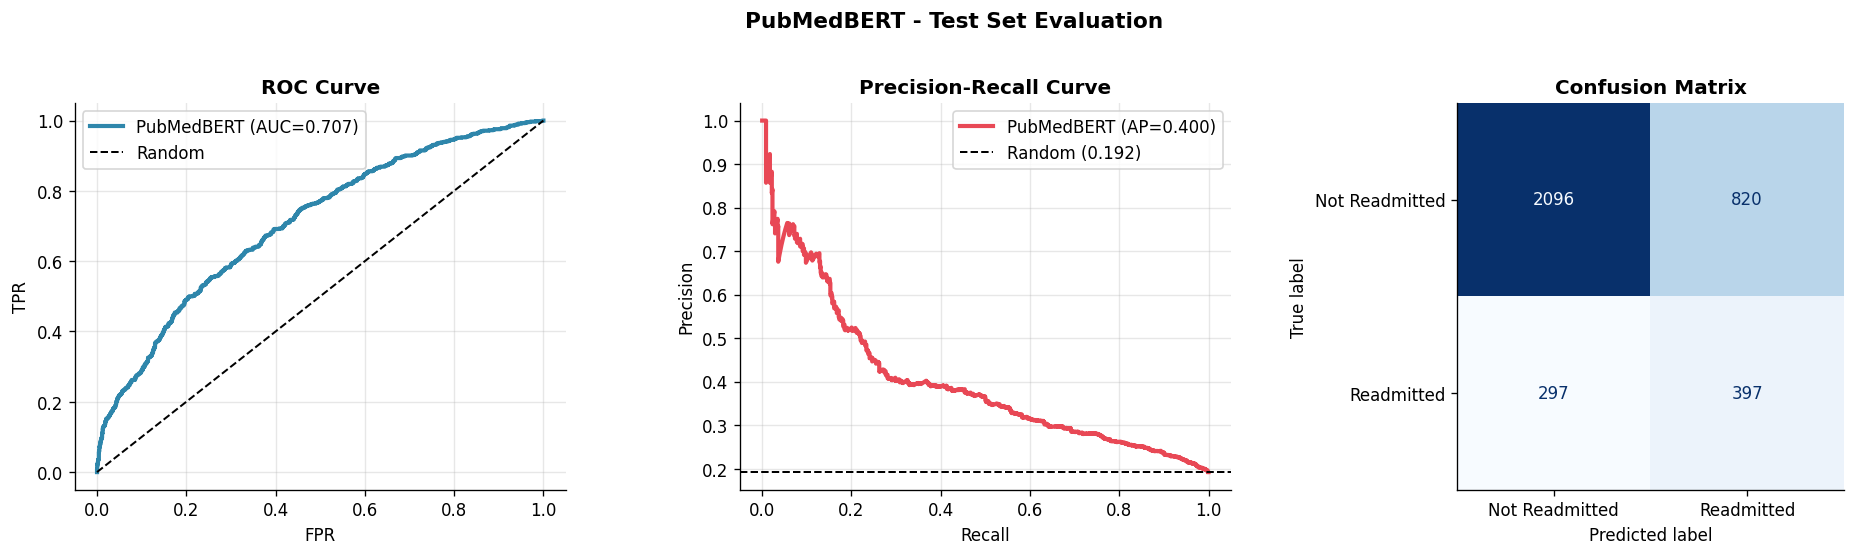

In [9]:
# Test Set Prediction
pred_out = trainer.predict(test_ds)

# Logits, Predicted Labels, and Probabilities
logits = pred_out.predictions
y_pred = np.argmax(logits, axis=-1)

y_prob = torch.softmax(
    torch.tensor(logits, dtype=torch.float32),
    dim=-1
).numpy()[:, 1]

# Evaluation Metrics (Test Set)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

# Results Output
print('\n PubMedBERT - Test Set Results ')
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Readmitted', 'Readmitted'],
    zero_division=0
))
print(f'ROC-AUC : {roc_auc:.4f}   PR-AUC : {pr_auc:.4f}')

# Curve Computation (ROC and Precision-Recall)
fpr, tpr, _  = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)

# Plot Evaluation Metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC Curve
axes[0].plot(
    fpr, tpr,
    color=PALETTE[0],
    lw=2.5,
    label=f'PubMedBERT (AUC={roc_auc:.3f})'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(
    rec, prec,
    color=PALETTE[1],
    lw=2.5,
    label=f'PubMedBERT (AP={pr_auc:.3f})'
)
axes[1].axhline(
    y=y_test.mean(),
    color='k',
    linestyle='--',
    lw=1.2,
    label=f'Random ({y_test.mean():.3f})'
)
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Not Readmitted', 'Readmitted']
).plot(ax=axes[2], colorbar=False, cmap='Blues')

axes[2].set_title('Confusion Matrix', fontweight='bold')

# Figure Formatting and Save
plt.suptitle(
    'PubMedBERT - Test Set Evaluation',
    fontsize=13,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()

plt.savefig(
    f'{PUBMEDBERT_PLOTS_DIR}/pm_02_test_evaluation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Prediction Confidence and Calibration Analysis 

This section examines the confidence distribution of PubMedBERT predictions to assess model calibration and decision reliability.

Predicted probabilities for the positive class (readmission) are analysed under two perspectives. First, confidence distributions are visualised separately for true class labels. Well-separated distributions indicate strong discriminative capability, while overlap suggests ambiguity in model predictions.

Second, prediction confidence is analysed based on correctness. A well-calibrated model should assign higher confidence to correct predictions and lower confidence to incorrect ones. This provides insight into the model’s reliability and potential overconfidence.

A decision threshold of 0.5 is included to illustrate how probabilities are converted into binary predictions. Observing the density of predictions around this threshold can highlight cases where classification decisions are uncertain.

This analysis complements standard evaluation metrics by offering a deeper understanding of model certainty, calibration behaviour, and potential areas for threshold optimisation.

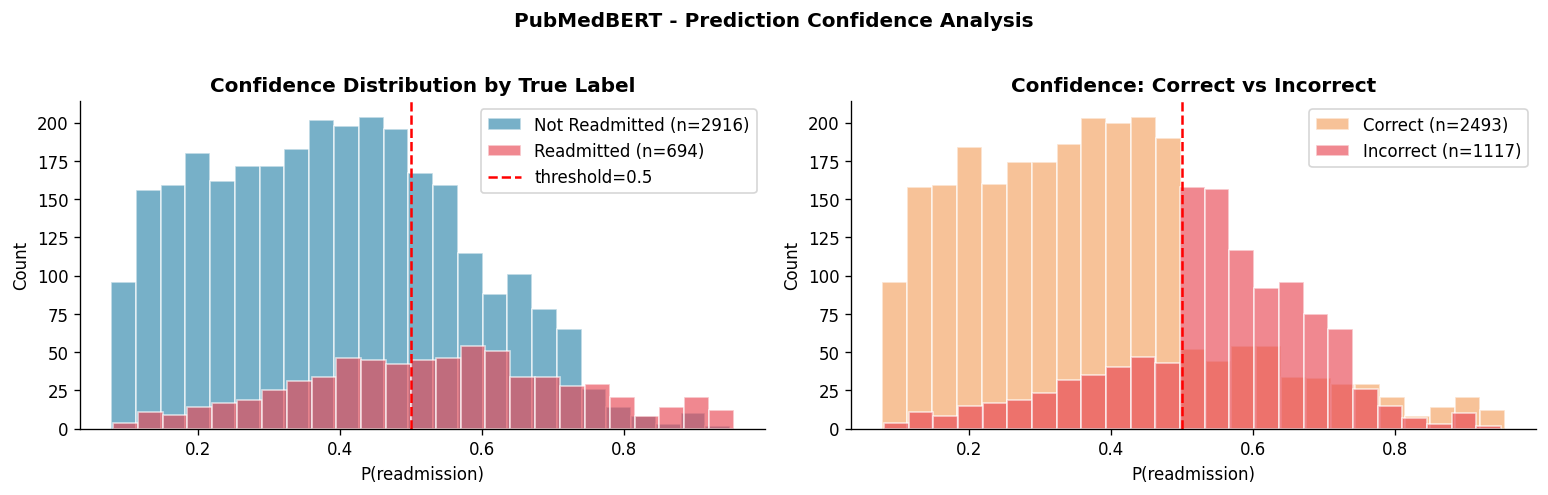

In [10]:
# Confidence Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confidence by True Label
for label, color, name in [
    (0, PALETTE[0], 'Not Readmitted'),
    (1, PALETTE[1], 'Readmitted')
]:
    sub = y_prob[y_test == label]

    axes[0].hist(
        sub,
        bins=25,
        alpha=0.65,
        color=color,
        edgecolor='white',
        label=f'{name} (n={len(sub)})'
    )

# Decision Threshold Line
axes[0].axvline(
    0.5,
    color='red',
    linestyle='--',
    lw=1.5,
    label='threshold=0.5'
)

axes[0].set_title('Confidence Distribution by True Label', fontweight='bold')
axes[0].set_xlabel('P(readmission)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Confidence by Prediction Correctness
correct = (y_pred == y_test)

for flag, color, lbl in [
    (True,  PALETTE[2], 'Correct'),
    (False, PALETTE[1], 'Incorrect')
]:
    sub = y_prob[correct == flag]

    axes[1].hist(
        sub,
        bins=25,
        alpha=0.65,
        color=color,
        edgecolor='white',
        label=f'{lbl} (n={len(sub)})'
    )

# Decision Threshold Line
axes[1].axvline(
    0.5,
    color='red',
    linestyle='--',
    lw=1.5
)

axes[1].set_title('Confidence: Correct vs Incorrect', fontweight='bold')
axes[1].set_xlabel('P(readmission)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Figure Formatting and Save
plt.suptitle(
    'PubMedBERT - Prediction Confidence Analysis',
    fontsize=12,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{PUBMEDBERT_PLOTS_DIR}/pm_03_confidence_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Results Persistence and Artefact Storage (PubMedBERT)

This section finalises the PubMedBERT evaluation pipeline by storing model performance metrics and prediction artefacts for reproducibility and downstream analysis.

Key evaluation metrics, including accuracy, precision, recall, F1-scores, ROC-AUC, and PR-AUC, are saved in a structured CSV format. This enables direct comparison with baseline models and other transformer architectures.

Additionally, prediction outputs and evaluation artefacts are serialised using pickle. These include true labels, predicted labels, predicted probabilities, and curve data for ROC and Precision–Recall analysis. Storing these artefacts allows results to be reproduced, re-evaluated, or visualised without requiring model retraining.

This step completes the PubMedBERT modelling pipeline and prepares the outputs for final comparison and reporting.

In [11]:
# Save Evaluation Metrics to CSV
pd.DataFrame([{
    'Model' : 'PubMedBERT',
    'Model_ID' : PUBMEDBERT_MODEL_ID,
    'Type' : 'Transformer',
    'Domain' : 'Biomedical (pre-trained from scratch on PubMed + PMC)',
    'Accuracy' : report['accuracy'],
    'Precision_Pos' : report['1']['precision'],
    'Recall_Pos' : report['1']['recall'],
    'F1_Pos' : report['1']['f1-score'],
    'F1_Weighted' : report['weighted avg']['f1-score'],
    'ROC_AUC' : roc_auc,
    'PR_AUC' : pr_auc,
}]).to_csv(
    PUBMEDBERT_RESULTS_CSV,
    index=False
)


# Save Predictions and Evaluation Artifacts (Pickle)
with open(PUBMEDBERT_PREDS_PKL, 'wb') as f:
    pickle.dump({
        'y_test' : y_test,
        'y_pred' : y_pred,
        'y_prob' : y_prob,
        'X_test' : X_test,
        'report' : report,
        'roc_auc' : roc_auc,
        'pr_auc' : pr_auc,
        'fpr' : fpr,
        'tpr' : tpr,
        'prec' : prec,
        'rec' : rec,
    }, f)

# Final Metric Summary
print(f'\nROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')


ROC-AUC : 0.7068  |  PR-AUC : 0.4003
